In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('HR_comma_sep.csv')
df.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


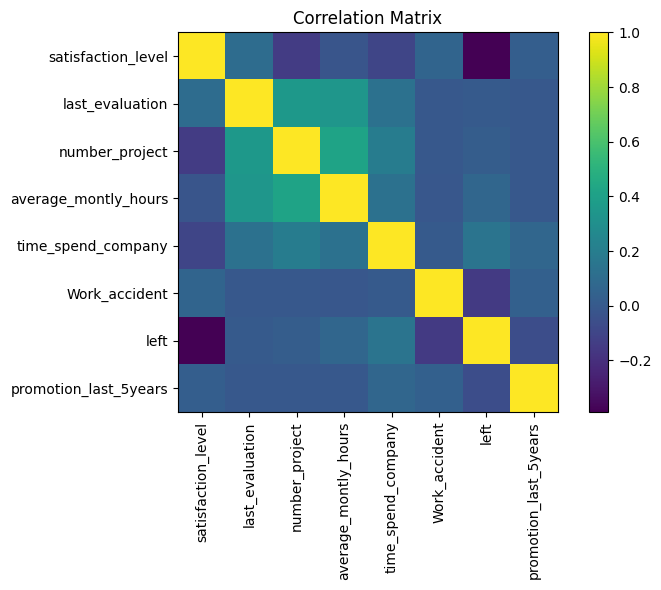

In [3]:
df_copy = df.copy()
corr_df = df.drop(["Department", "salary"], axis=1)
corr_matrix = corr_df.corr()
plt.figure(figsize=(8, 6))
plt.imshow(corr_matrix)
plt.colorbar()
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

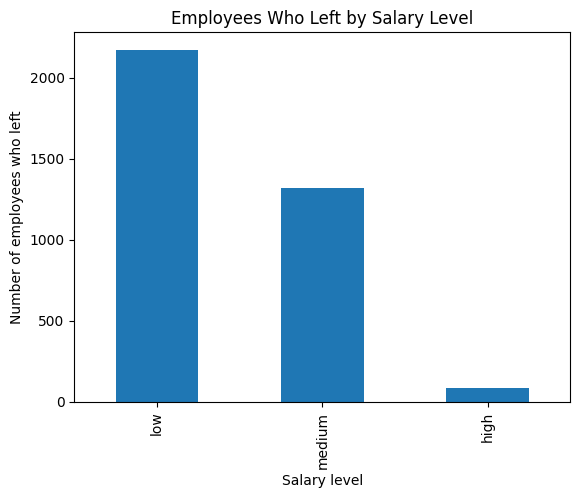

In [4]:
left_by_salary = df[df["left"] == 1]["salary"].value_counts()
plt.figure()
left_by_salary.plot(kind="bar")
plt.xlabel("Salary level")
plt.ylabel("Number of employees who left")
plt.title("Employees Who Left by Salary Level")
plt.show()

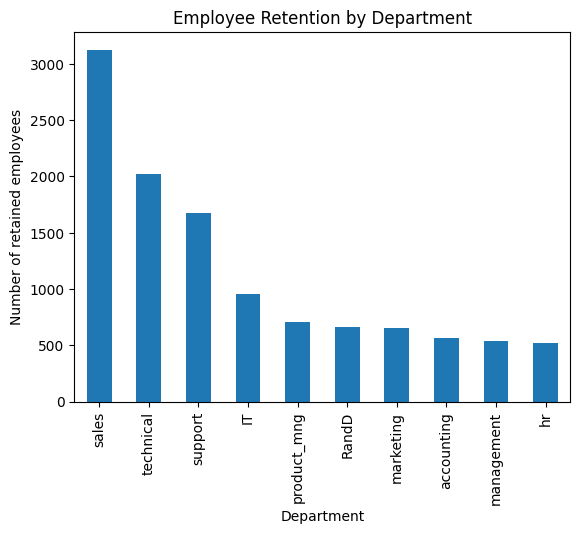

In [5]:
retention_by_dept = df[df["left"] == 0]["Department"].value_counts()
plt.figure()
retention_by_dept.plot(kind="bar")
plt.xlabel("Department")
plt.ylabel("Number of retained employees")
plt.title("Employee Retention by Department")
plt.show()

In [6]:
X = df.drop("left", axis=1)
Y = df['left']

In [7]:
salary_map = {"low": 0, "medium": 1, "high": 2}
X["salary"] = X["salary"].map(salary_map)

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [8]:
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

ohe = OneHotEncoder(sparse_output=False, drop="first")
dept_encoded = ohe.fit_transform(df[["Department"]])

dept_cols = ohe.get_feature_names_out(["Department"])
dept_df = pd.DataFrame(dept_encoded, columns=dept_cols)

X = df.drop("left", axis=1)
X = X.drop("Department", axis=1)

X = X.reset_index(drop=True)
dept_df = dept_df.reset_index(drop=True)

X = pd.concat([X, dept_df], axis=1)

In [9]:
salary_map = {"low": 0, "medium": 1, "high": 2}
X["salary"] = X["salary"].map(salary_map)

In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(X)

In [11]:
X = np.c_[np.ones(X.shape[0]), X]
weights = np.zeros(X.shape[1])

In [12]:
lr = 0.1
epochs = 1000

for _ in range(epochs):
    z = X @ weights
    y_hat = sigmoid(z)

    gradient = (X.T @ (y_hat - Y)) / len(Y)
    weights -= lr * gradient

In [13]:
y_pred = (sigmoid(X @ weights) >= 0.5).astype(int)

In [14]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(Y, y_pred))

Accuracy: 0.7947196479765317


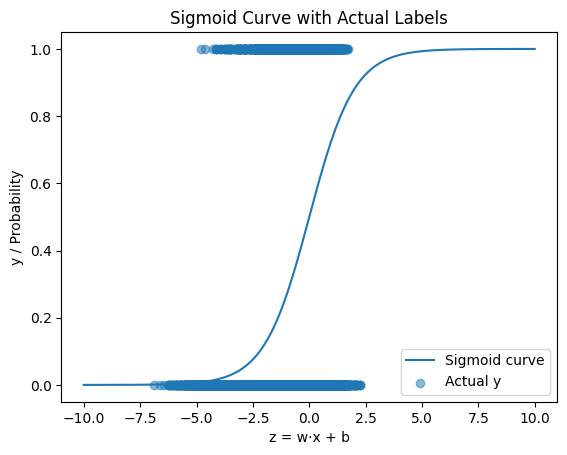

In [15]:
import numpy as np
import matplotlib.pyplot as plt

z_model = X @ weights
z_curve = np.linspace(-10, 10, 200)
y_curve = 1 / (1 + np.exp(-z_curve))
plt.figure()
plt.plot(z_curve, y_curve, label="Sigmoid curve")
plt.scatter(
    z_model,
    Y,
    alpha=0.5,
    label="Actual y"
)
plt.xlabel("z = w·x + b")
plt.ylabel("y / Probability")
plt.title("Sigmoid Curve with Actual Labels")
plt.legend()
plt.show()

In [18]:
df = pd.read_csv("zoo-data.csv")
df = df.drop(columns=["animal_name"])
print(df.head())

X = df.drop(columns=["class_type"]).values
y = df["class_type"].values

   hair  feathers  eggs  milk  airborne  aquatic  predator  toothed  backbone  \
0     1         0     0     1         0        0         1        1         1   
1     1         0     0     1         0        0         0        1         1   
2     0         0     1     0         0        1         1        1         1   
3     1         0     0     1         0        0         1        1         1   
4     1         0     0     1         0        0         1        1         1   

   breathes  venomous  fins  legs  tail  domestic  catsize  class_type  
0         1         0     0     4     0         0        1           1  
1         1         0     0     4     1         0        1           1  
2         0         0     1     0     1         0        0           4  
3         1         0     0     4     0         0        1           1  
4         1         0     0     4     1         0        1           1  


In [20]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix

In [21]:
num_classes = len(np.unique(y))

# Convert labels to 0-indexed
y = y - 1

Y = np.eye(num_classes)[y]

In [22]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

def softmax(z):
    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

In [23]:
m, n = X_train.shape
k = num_classes

W = np.zeros((n, k))
b = np.zeros((1, k))

lr = 0.05
epochs = 2000

for _ in range(epochs):
    # Forward
    z = X_train @ W + b
    y_hat = softmax(z)

    # Gradients
    dW = (X_train.T @ (y_hat - Y_train)) / m
    db = np.mean(y_hat - Y_train, axis=0, keepdims=True)

    # Update
    W -= lr * dW
    b -= lr * db

In [24]:
def predict(X):
    z = X @ W + b
    probs = softmax(z)
    return np.argmax(probs, axis=1)

y_pred = predict(X_test)
y_true = np.argmax(Y_test, axis=1)

cm = confusion_matrix(y_true, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[12  0  0  0  0  0]
 [ 0  2  0  0  0  0]
 [ 0  0  0  0  0  1]
 [ 0  0  0  2  0  0]
 [ 0  0  0  0  3  0]
 [ 0  0  0  0  0  1]]
